## Step 1 — Import Libraries

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

## Step 2 — Load Dataset

In [2]:

df = pd.read_csv("Sample - Superstore.csv", encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [4]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

## Step 3 — Convert Date Columns

In [5]:
# Convert to datetime

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

## Step 4 — Basic Exploration

In [6]:
print("Shape:", df.shape)

Shape: (9994, 21)


In [7]:
print("Columns:", df.columns)

Columns: Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')


In [8]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


## Step 5 — Feature Engineering

#### 1 Profit Ratio

In [9]:
df['Profit_Ratio'] = df['Profit'] / df['Sales']

Purpose: measure profitability of each order.

#### 2 Sales Per Item

In [10]:
df['Sales_per_Item'] = df['Sales'] / df['Quantity']

Purpose: approximate product price.

#### 3 Discount Amount

In [11]:
df['Discount_Amount'] = df['Sales'] * df['Discount']

Purpose: actual discount value.

#### 4 Shipping Time

In [12]:
df['Shipping_Time'] = (df['Ship Date'] - df['Order Date']).dt.days

Purpose: delivery efficiency.

#### 5 Order Month

In [13]:
df['Order_Month'] = df['Order Date'].dt.month

Purpose: seasonal trends.

#### 6 Order Year

In [14]:
df['Order_Year'] = df['Order Date'].dt.year

Purpose: yearly growth analysis.

#### 7 Order Day of Week

In [15]:
df['Order_Day'] = df['Order Date'].dt.day_name()

Purpose: best selling days.

#### 8 Weekend Flag

In [16]:
df['Is_Weekend'] = df['Order Date'].dt.weekday >= 5

Convert to int:

In [17]:
df['Is_Weekend'] = df['Is_Weekend'].astype(int)

#### 9 Profit per Item

In [18]:
df['Profit_per_Item'] = df['Profit'] / df['Quantity']

#### 10 Sales Category

Create buckets.

In [19]:
df['Sales_Category'] = pd.qcut(df['Sales'], q=3, labels=['Low','Medium','High'])

## Step 6 — Visualize Distribution Change

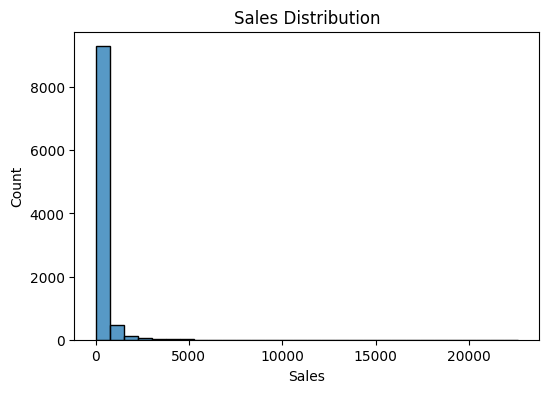

In [20]:
plt.figure(figsize=(6,4))
sns.histplot(df['Sales'], bins=30)
plt.title("Sales Distribution")
plt.show()

#### Profit Ratio:

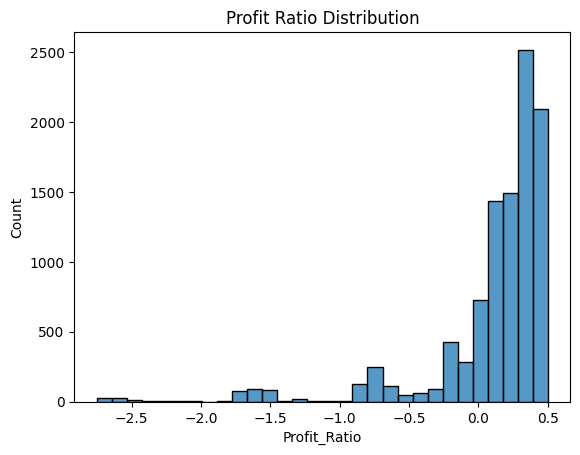

In [21]:
sns.histplot(df['Profit_Ratio'], bins=30)
plt.title("Profit Ratio Distribution")
plt.show()

## Step 7 — Encoding Categorical Variables

Machine learning requires numbers.

In [22]:
le = LabelEncoder()

df['Category_encoded'] = le.fit_transform(df['Category'])
df['Region_encoded'] = le.fit_transform(df['Region'])
df['Segment_encoded'] = le.fit_transform(df['Segment'])

## Step 8 — Feature Scaling

Scale numeric columns.

In [23]:
scaler = StandardScaler()

scale_cols = ['Sales','Profit','Quantity','Discount','Shipping_Time']

df[scale_cols] = scaler.fit_transform(df[scale_cols])

## Step 9 — Final Dataset

In [24]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Shipping_Time,Order_Month,Order_Year,Order_Day,Is_Weekend,Profit_per_Item,Sales_Category,Category_encoded,Region_encoded,Segment_encoded
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,-0.548318,11,2016,Tuesday,0,20.9568,High,0,2,0
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,-0.548318,11,2016,Tuesday,0,73.1940,High,0,2,0
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,0.023935,6,2016,Sunday,1,3.4357,Low,1,3,1
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,1.740693,10,2015,Sunday,1,-76.6062,High,0,2,0
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,1.740693,10,2015,Sunday,1,1.2582,Low,1,2,0


List new features.

In [25]:
new_features = [
'Profit_Ratio',
'Sales_per_Item',
'Discount_Amount',
'Shipping_Time',
'Order_Month',
'Order_Year',
'Is_Weekend',
'Profit_per_Item',
'Sales_Category'
]

print(new_features)

['Profit_Ratio', 'Sales_per_Item', 'Discount_Amount', 'Shipping_Time', 'Order_Month', 'Order_Year', 'Is_Weekend', 'Profit_per_Item', 'Sales_Category']


## Step 10 — Save Final Dataset

In [26]:
df.to_csv("superstore_feature_engineered.csv", index=False)